Business Question:
What team stats are strongly associated with winning? 

In [2]:
import pandas as pd

df = pd.read_csv("../data/nba_team_stats.csv")

df.head()


,TEAM_ID,TEAM_NAME,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,...,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,SEASON
0,1610612737,Atlanta Hawks,82,43,39,0.524,3941.0,3401,7241,0.470,...,15,1,22,23,10,7,6,6,14,2021-22
1,1610612738,Boston Celtics,82,51,31,0.622,3981.0,3341,7167,0.466,...,14,13,19,2,11,5,20,12,2,2021-22
2,1610612751,Brooklyn Nets,82,44,38,0.537,3951.0,3442,7251,0.475,...,10,17,24,5,21,22,16,9,15,2021-22
3,1610612766,Charlotte Hornets,82,43,39,0.524,3976.0,3508,7497,0.468,...,1,10,5,11,12,18,18,4,16,2021-22
4,1610612741,Chicago Bulls,82,46,36,0.561,3946.0,3422,7127,0.480,...,19,6,23,25,24,8,28,13,20,2021-22


In [3]:
df.shape

(120, 55)

In [4]:
df.columns

Index(['TEAM_ID', 'TEAM_NAME', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA',
       'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB',
       'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS',
       'PLUS_MINUS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK',
       'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK',
       'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK',
       'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK',
       'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK',
       'SEASON'],
      dtype='object')

In [5]:
analysis_cols = [
    'TEAM_NAME',
    'SEASON',
    'W',
    'L',
    'W_PCT',
    'PTS',
    'REB',
    'AST',
    'TOV',
    'FG_PCT',
    'FG3_PCT',
    'PLUS_MINUS'
]

analysis_df = df[analysis_cols]

analysis_df.head()

,TEAM_NAME,SEASON,W,L,W_PCT,PTS,REB,AST,TOV,FG_PCT,FG3_PCT,PLUS_MINUS
0,Atlanta Hawks,2021-22,43,39,0.524,9343,3606,2017,972.0,0.470,0.374,128.0
1,Boston Celtics,2021-22,51,31,0.622,9164,3778,2036,1118.0,0.466,0.356,597.0
2,Brooklyn Nets,2021-22,44,38,0.537,9258,3640,2071,1153.0,0.475,0.361,64.0
3,Charlotte Hornets,2021-22,43,39,0.524,9457,3655,2302,1087.0,0.468,0.365,36.0
4,Chicago Bulls,2021-22,46,36,0.561,9152,3471,1958,1053.0,0.480,0.369,-32.0


In [6]:
analysis_df.isnull().sum()

TEAM_NAME     0
SEASON        0
W             0
L             0
W_PCT         0
PTS           0
REB           0
AST           0
TOV           0
FG_PCT        0
FG3_PCT       0
PLUS_MINUS    0
dtype: int64

In [7]:
corr = analysis_df.select_dtypes(include='number').corr()

corr['W_PCT'].sort_values(ascending=False)

W_PCT         1.000000
W             0.999998
PLUS_MINUS    0.968971
FG3_PCT       0.674250
FG_PCT        0.608092
PTS           0.583755
AST           0.258251
REB           0.257520
TOV          -0.528283
L            -0.999998
Name: W_PCT, dtype: float64

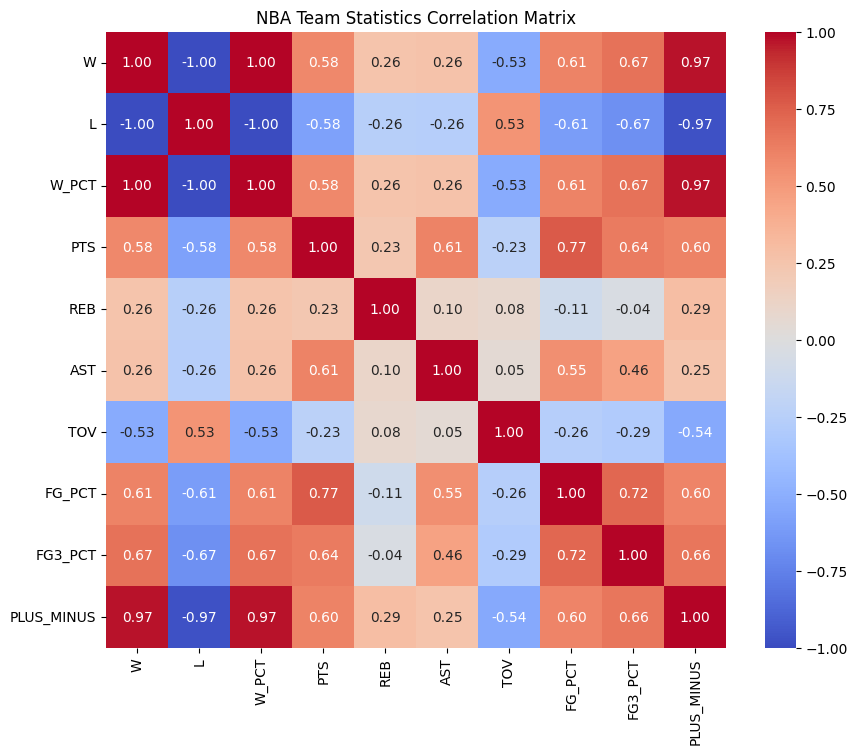

In [8]:
import matplotlib.pyplot as plt 
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr, 
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('NBA Team Statistics Correlation Matrix')

plt.show()

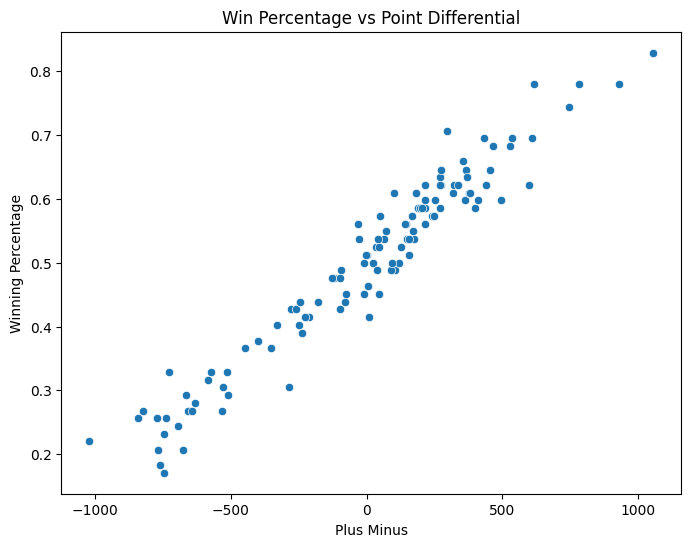

In [9]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=analysis_df,
    x='PLUS_MINUS',
    y='W_PCT'
)

plt.title('Win Percentage vs Point Differential')
plt.xlabel('Plus Minus')
plt.ylabel('Winning Percentage')

plt.show()

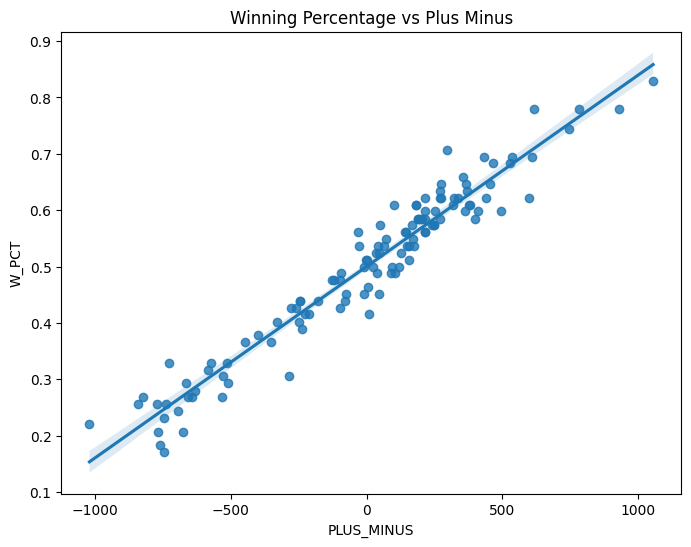

In [10]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=analysis_df,
    x='PLUS_MINUS',
    y='W_PCT'
)

plt.title('Winning Percentage vs Plus Minus')

plt.show()

Key Findings: 
1. Point differential (PLUS_MINUS) showed the strongest relationship with winning percentage.
2. Teams with higher field goal percentages generally won more games.
3. Assists were positively associated with team success. 
4. Turnovers showed a negative relationship with winning. 

In [11]:
corr['W_PCT'].sort_values(
    ascending=False
)

W_PCT         1.000000
W             0.999998
PLUS_MINUS    0.968971
FG3_PCT       0.674250
FG_PCT        0.608092
PTS           0.583755
AST           0.258251
REB           0.257520
TOV          -0.528283
L            -0.999998
Name: W_PCT, dtype: float64

In [13]:
[col for col in df.columns if 'RATING' in col]

[]

In [15]:
for col in df.columns:
    print(col)

TEAM_ID
TEAM_NAME
GP
W
L
W_PCT
MIN
FGM
FGA
FG_PCT
FG3M
FG3A
FG3_PCT
FTM
FTA
FT_PCT
OREB
DREB
REB
AST
TOV
STL
BLK
BLKA
PF
PFD
PTS
PLUS_MINUS
GP_RANK
W_RANK
L_RANK
W_PCT_RANK
MIN_RANK
FGM_RANK
FGA_RANK
FG_PCT_RANK
FG3M_RANK
FG3A_RANK
FG3_PCT_RANK
FTM_RANK
FTA_RANK
FT_PCT_RANK
OREB_RANK
DREB_RANK
REB_RANK
AST_RANK
TOV_RANK
STL_RANK
BLK_RANK
BLKA_RANK
PF_RANK
PFD_RANK
PTS_RANK
PLUS_MINUS_RANK
SEASON


In [16]:
corr_wpct = (
    corr["W_PCT"]
    .drop(["W_PCT", "W", "L"])
    .sort_values(ascending=False)
)

corr_wpct

PLUS_MINUS    0.968971
FG3_PCT       0.674250
FG_PCT        0.608092
PTS           0.583755
AST           0.258251
REB           0.257520
TOV          -0.528283
Name: W_PCT, dtype: float64

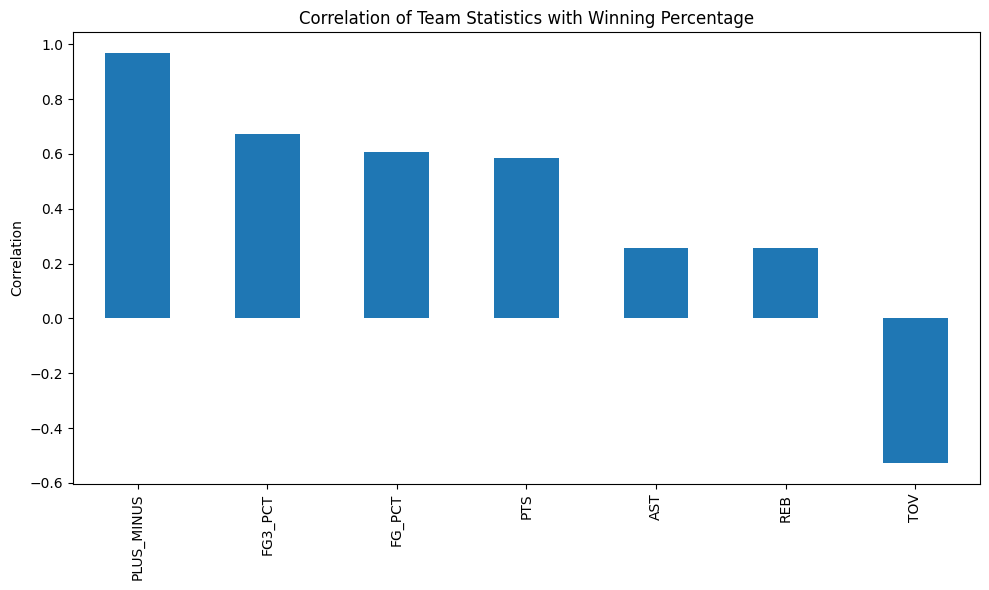

In [17]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(10,6))

corr_wpct.plot(
    kind="bar"
)

plt.title(
    "Correlation of Team Statistics with Winning Percentage"
)

plt.ylabel("Correlation")

plt.tight_layout()

plt.show()

## Executive Summary

This analysis examined NBA team performance across four seasons
(2021-22 through 2024-25) to determine which statistics are most
strongly associated with winning percentage.

Key Findings:

- Point differential (PLUS_MINUS) had the strongest positive
  relationship with winning percentage.

- Three-point shooting percentage showed a stronger relationship
  with winning than overall field goal percentage.

- Teams that committed more turnovers tended to have lower
  winning percentages.

- Rebounding and assists were positively related to winning,
  but less strongly than shooting efficiency metrics.